# Final Assignment and Groups
## Network Analysis and Economic Complexity for Sustainable Development

**Group 4**

- petr.ospaly@post.cz
- trngangiang889@gmail.com
- mesayunitira@gmail.com
- billdjelbahian@gmail.com
- pyaekyita@gmail.com

---

## Python boilerplate

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

class ECI:
    def __init__(self, countries, activities, matrix):
        self.countries = countries
        self.activities = activities
        self.matrix = matrix
        self.Mcp = np.array(matrix)
        self.G = self.create_graph()
        self.eci_index = []

    def diversification(self, Mcp=None):
        """Diversification: first order approximation of complexity"""

        if Mcp is None:
            Mcp = self.Mcp

        return Mcp.sum(axis = 1)

    def ubiquity(self, Mcp=None):
        """Ubiquity: first order approximation of complexity"""

        if Mcp is None:
            Mcp = self.Mcp

        return Mcp.sum(axis = 0)

    def get_countries_by_diversification(self):
        """Return index and name of countries sorted by diversification"""

        # Countries ordered with respect to their diversification
        order = np.argsort(self.diversification())[::-1]
        names = [self.countries[country] for country in order]

        return order, names

    def get_activities_by_ubiquity(self):
        """Return index and name of activities sorted by ubiquity"""

        order = np.argsort(self.ubiquity())[::-1]
        names = [self.activities[activity] for activity in order]

        return order, names

    def create_graph(self):
        """Create directed graph"""

        self.R, self.C = self.Mcp.shape

        G = nx.Graph()

        # Add country nodes
        G.add_nodes_from(self.countries, bipartite=0)

        # Add product nodes
        G.add_nodes_from(self.activities, bipartite=1)

        # Add edges where adjacency matrix is 1
        for i in range(self.R):
            for j in range(self.C):
                if self.Mcp[i, j] == 1:
                    G.add_edge(self.countries[i], self.activities[j])

        return G


    def show_graph(self, sizex=6, sizey=6):
        """Show directed graph"""


        # Positioning using bipartite layout
        pos = nx.bipartite_layout(self.G, self.countries)

        # Plot the graph
        fig,ax = plt.subplots(1,1,figsize=(sizex, sizey))
        node_colors = ['lightblue' if node in self.countries else 'darkblue' for node in self.G.nodes()]

        nx.draw_networkx(self.G, pos, edge_color='lightgray', node_color=node_colors, node_size=2500,font_size=12,font_color='grey')

        #Give more space for the names
        x1,x2=ax.get_xlim()
        plt.xlim([x1-0.2,x2])

        plt.title("Directed graph")

        plt.show()

    def show_matrix(self, sizex=6, sizey=6):
        """Show an adjacency Matrix"""

        #plt.figure(figsize=(sizex, sizey))
        plt.pcolor(self.Mcp,cmap='Blues')

        plt.gca().invert_yaxis() # Flip the y axis to have the first row on top.
        plt.yticks([i+0.5 for i in range(len(countries))], countries, rotation=45)

        plt.title("Original matrix")

        plt.show()

    def show_triangle(self, sizex=6, sizey=6):
        """Show a sorted adjacency Matrix"""

        #plt.figure(figsize=(sizex, sizey))
        #_, ax = plt.subplots()

        # Countries ordered with respect to their diversification
        order, names = self.get_countries_by_diversification()
        triangle = []

        for i in order:
            triangle.append(self.matrix[i])

        plt.pcolor(triangle,cmap='Blues')

        plt.gca().invert_yaxis() # Flip the y axis to have the first row on top.
        plt.yticks([i+0.5 for i in range(len(self.countries))], names, rotation=45)

        #ax.set_title("Countries sorted by diversification")
        plt.title("Countries sorted by diversification")

        plt.show()

    def show_diversification(self):
        """Show highlighted diversification - to compare with my triangle"""

        #diversification = np.sum(Mcp, axis = 1)
        #order_countries = np.argsort(diversification)[::-1]
        #
        #ubiquity = np.sum(Mcp, axis = 0)
        #order_products = np.argsort(ubiquity)[::-1]

        order_countries, _ = self.get_countries_by_diversification()
        order_products, _ = self.get_activities_by_ubiquity()

        ordered_Mcp = np.zeros(np.shape(self.Mcp))

        for c in range(len(order_countries)):
            for p in range(len(order_products)):
                ordered_Mcp[c,p] = self.Mcp[order_countries[c],order_products[p]]

        plt.matshow(ordered_Mcp, cmap = 'Blues')
        plt.yticks(range(self.R),[self.countries[i] for i in order_countries])
        plt.title("This is lecture chart - activities must have been shift around")

        plt.show()

    def show_ubiquity(self):
        """Show bar chart of most common activities"""

        ubiquity = self.ubiquity()
        order, names = self.get_activities_by_ubiquity()
        count = []
        for i in order:
            count.append(ubiquity[i])

        plt.bar(names, count)
        plt.title("Ubiquity of Activities")
        plt.ylabel("How many countries")
        plt.show()

    def show_eci(self, unsign=False, sizex=6, sizey=6):
        """Show ECI indices for the countries"""

        if len(self.eci_index) <= 0:
            raise ValueError("No method was used to set ECI indices")

        if unsign:
            eci = [abs(i) for i in self.eci_index]
        else:
            eci = self.eci_index

        plt.figure(figsize=(sizex, sizey))
        plt.scatter(self.countries, eci)
        plt.xticks([i for i in range(len(self.countries))], self.countries, rotation=45)
        plt.ylabel("ECI")
        plt.title("Scatter plot of ECI values")
        plt.show()

    def print(self):
        """Print initial summary"""

        diversification = self.diversification()

        print(f"Original countries:")
        for i in range(len(self.countries)):
            print(f"\tindex '{i:2}' - {self.countries[i]:20} (sum: {diversification[i]})")

        print(f"List of activities:")
        for i in range(len(self.activities)):
            print(f"\tindex '{i:2}' - {self.activities[i]}")

        print(f"Matrix:")
        for line in self.matrix:
            print(f"\t{line}")

        print("\n--- --- ---\n")

    def print_diversification(self):
        """Print sorted countries by diversification"""

        diversification = self.diversification()
        order, names = self.get_countries_by_diversification()

        print(f"Countries sorted by diversification (Most diverse at the top):")
        for pos, i in enumerate(order):
            print(f"\t{pos+1}. - {names[pos]:20} (diversification: {diversification[i]})")

        print("--- --- ---")

    def print_ubiquity(self):
        """Print sorted activities by ubiquity"""

        ubiquity = self.ubiquity()
        order, names = self.get_activities_by_ubiquity()

        print(f"Activities sorted by ubiquity (Most common at the top):")
        for pos, i in enumerate(order):
            print(f"\t{pos+1}. - {names[pos]:5} (ubiquity: {ubiquity[i]})")

        print("--- --- ---")

    def OneStep(self, kc=None, kp=None):
        """Function to compute kc(N+1) and kp(N+1) given Mcp and the previous step, kc(N) and kp(N)"""

        diversification = self.diversification()
        ubiquity = self.ubiquity()

        if kc is None:
            kc = diversification

        if kp is None:
            kp = ubiquity

        kc1 = self.Mcp.dot(kp)/diversification
        kp1 = self.Mcp.transpose().dot(kc)/ubiquity

        return kc1, kp1


    def MethodOfReflections(self, max_iterations=10):
        """Function to initialize kc(0) and kp(0), iterate OneStep max_iterations times, and normalize the output"""

        diversification = self.diversification()
        ubiquity = self.ubiquity()

        # Setting the initial condition
        kc = diversification / diversification.sum()
        kp = ubiquity / ubiquity.sum()

        for iteration in range(max_iterations):
            kc, kp = self.OneStep(kc, kp)

        return (kc - kc.mean())/kc.std(), (kp - kp.mean())/kp.std()

    def _print_indices(self, indices):
        for country_index, i in enumerate(indices):
            print(f"\t{country_index:2}: {self.countries[country_index]:20} = {i:.5}")

    def _print_sorted_indices(self, indices, unsign=False):
        if unsign:
            indices = [abs(i) for i in indices]

        order_countries = np.argsort(indices)[::-1]

        for pos, i in enumerate(order_countries):
            print(f"\t{pos+1}. - ({i:1}) {self.countries[i]:20} = {indices[i]:.5}")

    def _save_indices(self, indices, unsign=False):
        self.eci_index = []
        for i in indices:
            if unsign:
                self.eci_index.append(abs(i))
            else:
                self.eci_index.append(i)

    def do_method_of_reflections_once(self):
        """Compute one step, starting from diversification and ubiquity"""

        kc, _ = self.OneStep()
        print("Method of Reflections (One Step only):")
        self._print_indices(kc)
        print("--- --- ---")

    def do_method_of_reflections(self, iterations=10):
        """Compute ECI with the MethodOfReflections"""

        kc, _ = self.MethodOfReflections(iterations)
        print(f"Method of Reflections (Iterations: {iterations}):")
        self._print_indices(kc)
        print("---")

        # store the index for chart
        #self.eci_index = kc
        self._save_indices(kc)

        #Print the order
        print("Ordered:")
        self._print_sorted_indices(kc)
        print("Ordered (sign removed):")
        self._print_sorted_indices(kc, True)

        print("--- --- ---")

    def do_eigen_values(self):
        """ECI as an eigenvalue problem"""

        Mcp = self.Mcp

        # Projecting Matrices
        Ccc = np.matmul(np.array(Mcp.transpose()/np.sum(Mcp,1)).transpose(),np.array(Mcp/np.sum(Mcp,0)).transpose())
        Cpp = np.matmul(np.array(Mcp/np.sum(Mcp,0)).transpose(),np.array(Mcp.transpose()/np.sum(Mcp,1)).transpose())

        # Compute eigenvalues and eigenvectors
        eigvalues, eigvectors = np.linalg.eig(Ccc)

        # ECI is the eigenvector corresponding to the second largest eigenvalue
        ECI = eigvectors[:,eigvalues.argsort()[-2]]

        # Normalizing ECI
        ECI = (ECI - ECI.mean())/ECI.std()

        print(f"ECI as an eigenvalue problem:")
        self._print_indices(ECI)
        print("---")

        # store the index for chart
        self._save_indices(ECI)

        #Print the order
        print("Ordered:")
        self._print_sorted_indices(ECI)
        print("Ordered (sign removed):")
        self._print_sorted_indices(ECI, True)

        print("--- --- ---")

    def fitCompOneStep(self, Fitness):
        """Algorithm to compute Fitness and Complexity"""

        C = self.C

        #One step of the algorithm
        Complexity=np.zeros(C)
        for p in range(C):
            try:
                sumCT=self.Mcp[:,p]/Fitness
                sumCT[np.where(np.isnan(sumCT))]=0.
                sumCT=sumCT*(1-np.isnan(sumCT))
                Complexity[p] = 1./np.sum(sumCT)
                if np.isnan(Complexity[p]):
                    Complexity[p]=0
            except ZeroDivisionError:
                Complexity[p] = 0
        Fitness = np.dot(self.Mcp, Complexity)
        return Fitness/np.mean(Fitness),Complexity/np.mean(Complexity)

    def FitnessComplexity(self, max_iterations=10):

        diversification = self.diversification()
        ubiquity = self.ubiquity()

        # Setting the initial condition
        F = diversification / diversification.sum()
        Q = ubiquity / ubiquity.sum()

        for iteration in range(max_iterations):
            F,Q = self.fitCompOneStep(F)

        return (F / F.mean()), (Q/Q.mean())

    def show_fitness(self, iterations=10):
        N = iterations
        Fseries=[]
        for iteration in range(N):
            F, Q = self.FitnessComplexity(iteration)
            Fseries.append(F)
        Fseries=np.array(Fseries)

        fig,ax=plt.subplots(1,1,)
        plt.plot(Fseries)
        plt.xlabel('Iteration')
        plt.ylabel('Fitness')
        plt.xticks(range(0,N,5),range(0,N,5))
        plt.title("Chart of Fitness")
        plt.show()

    def show_fitness_and_complexity(self, iterations=10):
        """Fitness and Complexity"""

        F, Q = self.FitnessComplexity(iterations)
        order_countries = np.argsort(F)[::-1]

        ubiquity = self.ubiquity()
        order_products = np.argsort(Q)

        ordered_Mcp = np.zeros(np.shape(self.Mcp))

        for c in range(len(order_countries)):
            for p in range(len(order_products)):
                ordered_Mcp[c,p] = self.Mcp[order_countries[c],order_products[p]]

        plt.matshow(ordered_Mcp, cmap = 'Blues')
        plt.yticks(range(self.R),[countries[i] for i in order_countries], rotation=45)
        plt.xticks(range(self.C),[activities[i] for i in order_products])

        plt.title("Fitness and Complexity")
        plt.show()

    def calc_cooccurrencies(self):
        self.Jpp = self.Mcp.transpose().dot(self.Mcp)
        return self.Jpp

    def print_cooccurrencies(self):
        self.calc_cooccurrencies()
        print("Relatedness / Co-occurrencies")
        print(self.Jpp)
        print("--- --- ---")

    def ProductSpace(self):
        Jpp = self.calc_cooccurrencies()
        ubiquity = self.ubiquity()

        ubiMat = np.tile(ubiquity,[self.Mcp.shape[1],1])
        ubiMax = np.maximum(ubiMat,np.transpose(ubiMat)).astype(float)

        np.divide(np.ones_like(ubiMax,dtype=float), ubiMax, out=ubiMax, where=ubiMax != 0)
        return np.multiply(Jpp,ubiMax)

    def Taxonomy(self):
        diversification = self.diversification()
        ubiquity = self.ubiquity()
        Mcp = self.Mcp

        Jpp = Mcp.transpose().dot(np.diag(1/diversification).dot(Mcp))

        ubiMat = np.tile(ubiquity,[Mcp.shape[1],1])
        ubiMax = np.maximum(ubiMat,np.transpose(ubiMat)).astype(float)

        np.divide(np.ones_like(ubiMax,dtype=float), ubiMax, out=ubiMax, where=ubiMax != 0)
        return np.multiply(Jpp,ubiMax)

    def AssistMatrix(self):
        diversification = self.diversification()
        ubiquity = self.ubiquity()
        Mcp = self.Mcp

        Jpp = Mcp.transpose().dot(np.diag(1/diversification).dot(Mcp))

        ubiMat = np.tile(ubiquity,[Mcp.shape[1],1]).astype('float')

        np.divide(np.ones_like(ubiMat,dtype=float), ubiMat, out=ubiMat, where=ubiMat != 0)

        return np.multiply(Jpp,ubiMat)

    def print_relatedness(self, count=4):
        """Print the relatedness among the first activities/products"""

        print(f"Relatedness / Product Space ({count} products)")
        print(self.ProductSpace()[:count,:count])
        print("---")

        print(f"Relatedness / Taxonomy ({count} products)")
        print(self.Taxonomy()[:count,:count])
        print("---")

        # Notice how the Assist Matrix is not symmetric
        print(f"Relatedness / Assist Matrix ({count} products)")
        print(self.AssistMatrix()[:count,:count])
        print("--- --- ---")

    def show_relatedness(self, threshold=0.1):
        Bpp = self.Taxonomy()
        C = self.C

        G = nx.Graph()
        G.add_nodes_from(self.activities)
        G.add_edges_from([ ('P'+str(i),'P'+str(j)) for i in range(C) for j in range(C) if Bpp[i,j]>threshold])

        nx.draw_networkx(G, pos=nx.spring_layout(G,k=2/np.sqrt(C)), edge_color='lightgray', node_color='lightblue', node_size=2500,font_size=12,font_color='grey')

        plt.show()


---

## Main section

---

### Initialization and Data

In [2]:
# Define matrix, connecting (imaginary) countries and activities.

countries=['Vale of Arryn','The North','The Riverlands', 'Dorne', 'The Stormland','The Westerlands','The Reach']
activities=[f'P{j}' for j in range(9)]

matrix = [[1, 0, 1, 0, 1, 1, 0, 0, 1],
          [0, 1, 1, 0, 0, 1, 1, 0, 0],
          [0, 1, 0, 1, 1, 0, 0, 0, 0],
          [1, 0, 1, 0, 0, 0, 0, 0, 0],
          [0, 0, 0, 0, 0, 1, 1, 0, 1],
          [0, 1, 1, 0, 1, 0, 1, 1, 1],
          [1, 1, 1, 1, 1, 0, 1, 1, 1]]


In [3]:
Index1 = ECI(countries, activities, matrix)
Index1.print()

Original countries:
	index ' 0' - Vale of Arryn        (sum: 5)
	index ' 1' - The North            (sum: 4)
	index ' 2' - The Riverlands       (sum: 3)
	index ' 3' - Dorne                (sum: 2)
	index ' 4' - The Stormland        (sum: 3)
	index ' 5' - The Westerlands      (sum: 6)
	index ' 6' - The Reach            (sum: 8)
List of activities:
	index ' 0' - P0
	index ' 1' - P1
	index ' 2' - P2
	index ' 3' - P3
	index ' 4' - P4
	index ' 5' - P5
	index ' 6' - P6
	index ' 7' - P7
	index ' 8' - P8
Matrix:
	[1, 0, 1, 0, 1, 1, 0, 0, 1]
	[0, 1, 1, 0, 0, 1, 1, 0, 0]
	[0, 1, 0, 1, 1, 0, 0, 0, 0]
	[1, 0, 1, 0, 0, 0, 0, 0, 0]
	[0, 0, 0, 0, 0, 1, 1, 0, 1]
	[0, 1, 1, 0, 1, 0, 1, 1, 1]
	[1, 1, 1, 1, 1, 0, 1, 1, 1]

--- --- ---



---

### Visualize the network

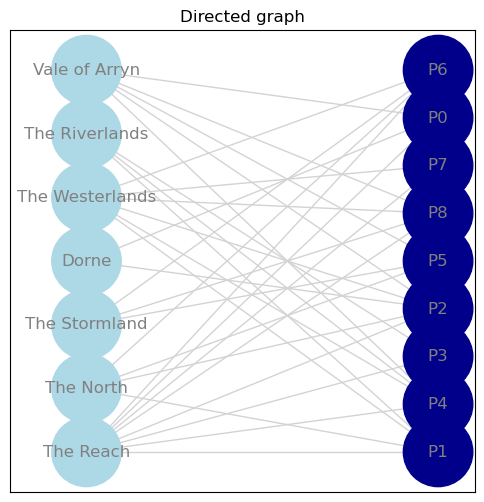

In [4]:
Index1.show_graph()

---

### Visualize the matrix

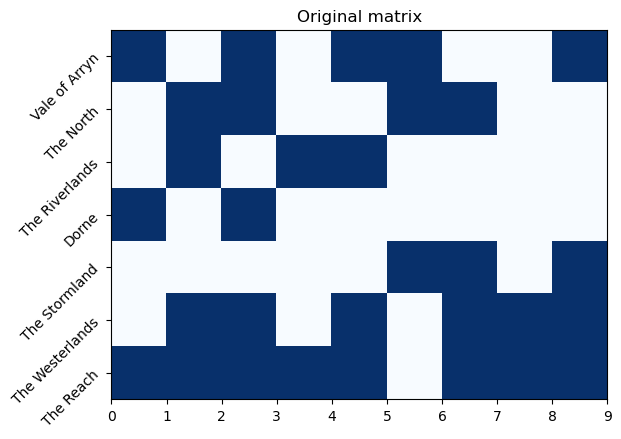

In [5]:
Index1.show_matrix()

---

### Assessing the complexity of countries

In [6]:
Index1.print_diversification()

Countries sorted by diversification (Most diverse at the top):
	1. - The Reach            (diversification: 8)
	2. - The Westerlands      (diversification: 6)
	3. - Vale of Arryn        (diversification: 5)
	4. - The North            (diversification: 4)
	5. - The Stormland        (diversification: 3)
	6. - The Riverlands       (diversification: 3)
	7. - Dorne                (diversification: 2)
--- --- ---


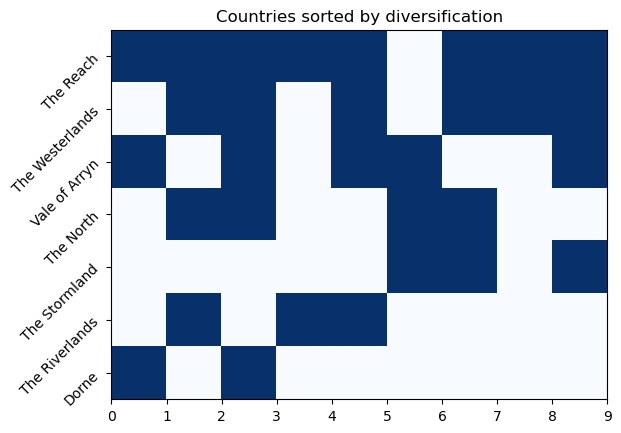

In [7]:
Index1.show_triangle()

---

### Nestedness

*Notice that Activity/Product Numbers do not match the actual numbers...*

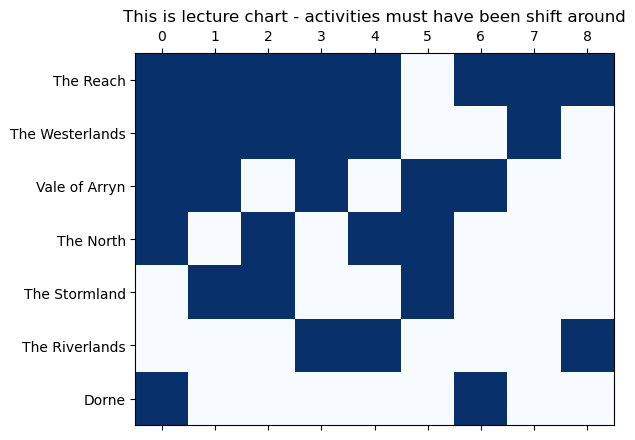

In [8]:
Index1.show_diversification()

---

### Ubiquity

In [9]:
Index1.print_ubiquity()

Activities sorted by ubiquity (Most common at the top):
	1. - P2    (ubiquity: 5)
	2. - P8    (ubiquity: 4)
	3. - P6    (ubiquity: 4)
	4. - P4    (ubiquity: 4)
	5. - P1    (ubiquity: 4)
	6. - P5    (ubiquity: 3)
	7. - P0    (ubiquity: 3)
	8. - P7    (ubiquity: 2)
	9. - P3    (ubiquity: 2)
--- --- ---


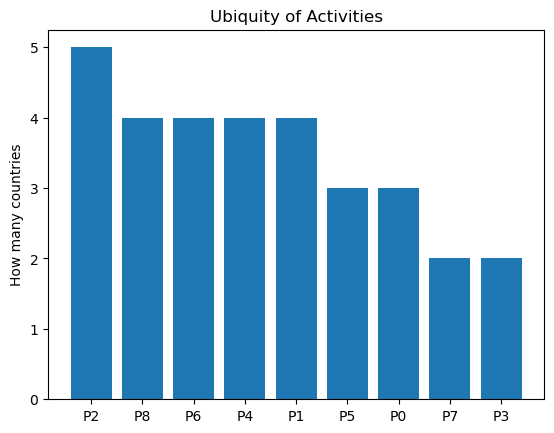

In [10]:
Index1.show_ubiquity()

---

### Method of Reflections

- First one step only
- Then 10 iterations (even number)
- Then 19 iterations (odd number)

(For comparison)

In [11]:
Index1.do_method_of_reflections_once()

Method of Reflections (One Step only):
	 0: Vale of Arryn        = 3.8
	 1: The North            = 4.0
	 2: The Riverlands       = 3.3333
	 3: Dorne                = 4.0
	 4: The Stormland        = 3.6667
	 5: The Westerlands      = 3.8333
	 6: The Reach            = 3.5
--- --- ---


In [12]:
Index1.do_method_of_reflections()

Method of Reflections (Iterations: 10):
	 0: Vale of Arryn        = -0.56652
	 1: The North            = -0.50457
	 2: The Riverlands       = 2.0324
	 3: Dorne                = -0.67374
	 4: The Stormland        = -1.1872
	 5: The Westerlands      = 0.33608
	 6: The Reach            = 0.56354
---
Ordered:
	1. - (2) The Riverlands       = 2.0324
	2. - (6) The Reach            = 0.56354
	3. - (5) The Westerlands      = 0.33608
	4. - (1) The North            = -0.50457
	5. - (0) Vale of Arryn        = -0.56652
	6. - (3) Dorne                = -0.67374
	7. - (4) The Stormland        = -1.1872
Ordered (sign removed):
	1. - (2) The Riverlands       = 2.0324
	2. - (4) The Stormland        = 1.1872
	3. - (3) Dorne                = 0.67374
	4. - (0) Vale of Arryn        = 0.56652
	5. - (6) The Reach            = 0.56354
	6. - (1) The North            = 0.50457
	7. - (5) The Westerlands      = 0.33608
--- --- ---


In [13]:
Index1.do_method_of_reflections(19)

Method of Reflections (Iterations: 19):
	 0: Vale of Arryn        = 0.57397
	 1: The North            = 0.45588
	 2: The Riverlands       = -2.0584
	 3: Dorne                = 0.76801
	 4: The Stormland        = 1.1159
	 5: The Westerlands      = -0.31634
	 6: The Reach            = -0.53896
---
Ordered:
	1. - (4) The Stormland        = 1.1159
	2. - (3) Dorne                = 0.76801
	3. - (0) Vale of Arryn        = 0.57397
	4. - (1) The North            = 0.45588
	5. - (5) The Westerlands      = -0.31634
	6. - (6) The Reach            = -0.53896
	7. - (2) The Riverlands       = -2.0584
Ordered (sign removed):
	1. - (2) The Riverlands       = 2.0584
	2. - (4) The Stormland        = 1.1159
	3. - (3) Dorne                = 0.76801
	4. - (0) Vale of Arryn        = 0.57397
	5. - (6) The Reach            = 0.53896
	6. - (1) The North            = 0.45588
	7. - (5) The Westerlands      = 0.31634
--- --- ---


---

### Chart ECI

Do with Method of Reflections and iterations 20

- with a sign
- without a sign

In [14]:
Index1.do_method_of_reflections(20)

Method of Reflections (Iterations: 20):
	 0: Vale of Arryn        = -0.55986
	 1: The North            = -0.48475
	 2: The Riverlands       = 2.054
	 3: Dorne                = -0.68683
	 4: The Stormland        = -1.1712
	 5: The Westerlands      = 0.30378
	 6: The Reach            = 0.54483
---
Ordered:
	1. - (2) The Riverlands       = 2.054
	2. - (6) The Reach            = 0.54483
	3. - (5) The Westerlands      = 0.30378
	4. - (1) The North            = -0.48475
	5. - (0) Vale of Arryn        = -0.55986
	6. - (3) Dorne                = -0.68683
	7. - (4) The Stormland        = -1.1712
Ordered (sign removed):
	1. - (2) The Riverlands       = 2.054
	2. - (4) The Stormland        = 1.1712
	3. - (3) Dorne                = 0.68683
	4. - (0) Vale of Arryn        = 0.55986
	5. - (6) The Reach            = 0.54483
	6. - (1) The North            = 0.48475
	7. - (5) The Westerlands      = 0.30378
--- --- ---


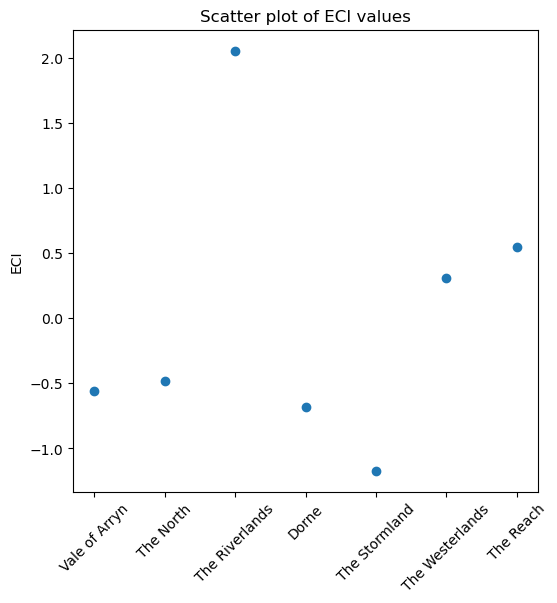

In [15]:
# keep sign
Index1.show_eci()

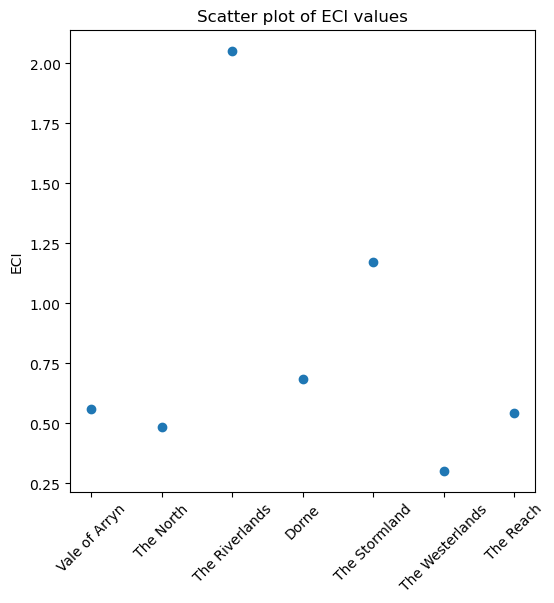

In [16]:
# removing sign and reordering
Index1.show_eci(True)

---

### ECI with eigenvalues

In [17]:
Index1.do_eigen_values()

ECI as an eigenvalue problem:
	 0: Vale of Arryn        = -0.56136
	 1: The North            = -0.48151
	 2: The Riverlands       = 2.0548
	 3: Dorne                = -0.6958
	 4: The Stormland        = -1.1651
	 5: The Westerlands      = 0.30489
	 6: The Reach            = 0.54408
---
Ordered:
	1. - (2) The Riverlands       = 2.0548
	2. - (6) The Reach            = 0.54408
	3. - (5) The Westerlands      = 0.30489
	4. - (1) The North            = -0.48151
	5. - (0) Vale of Arryn        = -0.56136
	6. - (3) Dorne                = -0.6958
	7. - (4) The Stormland        = -1.1651
Ordered (sign removed):
	1. - (2) The Riverlands       = 2.0548
	2. - (4) The Stormland        = 1.1651
	3. - (3) Dorne                = 0.6958
	4. - (0) Vale of Arryn        = 0.56136
	5. - (6) The Reach            = 0.54408
	6. - (1) The North            = 0.48151
	7. - (5) The Westerlands      = 0.30489
--- --- ---


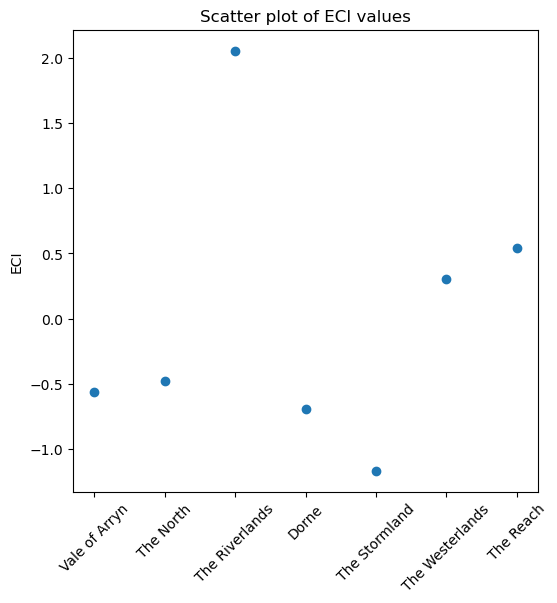

In [18]:
# keep sign
Index1.show_eci()

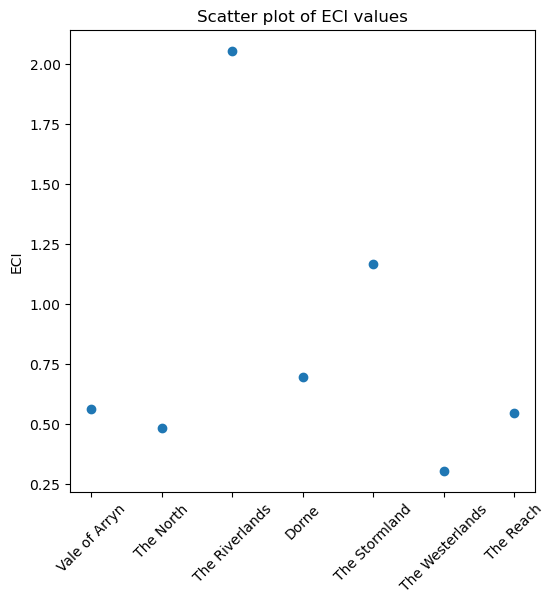

In [19]:
# removing sign
Index1.show_eci(True)

---

## Fitness and Complexity - another index of Complexity

---

### Fitness

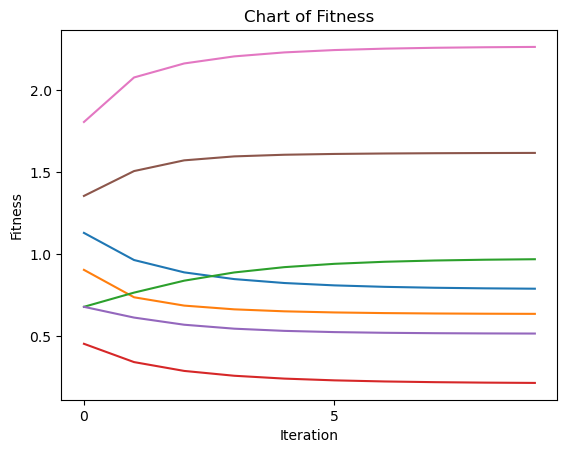

In [20]:
Index1.show_fitness()

---

### Fitness and Complexity

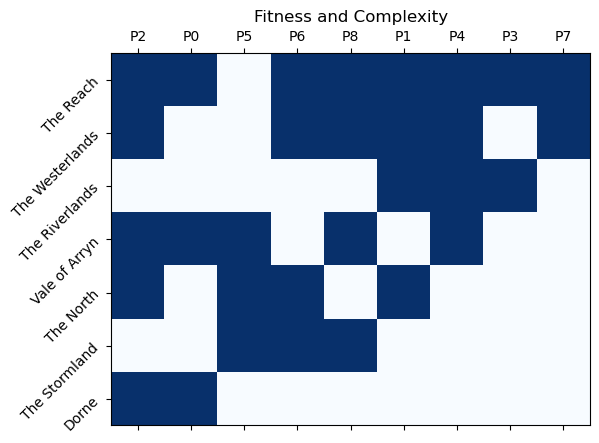

In [21]:
Index1.show_fitness_and_complexity()

---

## Relatedness

### Co-occurrencies

In [22]:
Index1.print_cooccurrencies()

Relatedness / Co-occurrencies
[[3 1 3 1 2 1 1 1 2]
 [1 4 3 2 3 1 3 2 2]
 [3 3 5 1 3 2 3 2 3]
 [1 2 1 2 2 0 1 1 1]
 [2 3 3 2 4 1 2 2 3]
 [1 1 2 0 1 3 2 0 2]
 [1 3 3 1 2 2 4 2 3]
 [1 2 2 1 2 0 2 2 2]
 [2 2 3 1 3 2 3 2 4]]
--- --- ---


---

### Relatedness (4 product space)

In [23]:
Index1.print_relatedness()

Relatedness / Product Space (4 products)
[[1.         0.25       0.6        0.33333333]
 [0.25       1.         0.6        0.5       ]
 [0.6        0.6        1.         0.2       ]
 [0.33333333 0.5        0.2        1.        ]]
---
Relatedness / Taxonomy (4 products)
[[0.275      0.03125    0.165      0.04166667]
 [0.03125    0.21875    0.10833333 0.11458333]
 [0.165      0.10833333 0.24833333 0.025     ]
 [0.04166667 0.11458333 0.025      0.22916667]]
---
Relatedness / Assist Matrix (4 products)
[[0.275      0.03125    0.165      0.0625    ]
 [0.04166667 0.21875    0.10833333 0.22916667]
 [0.275      0.13541667 0.24833333 0.0625    ]
 [0.04166667 0.11458333 0.025      0.22916667]]
--- --- ---


---

### Show Network of Taxonomy

**Threshold `0.1`**

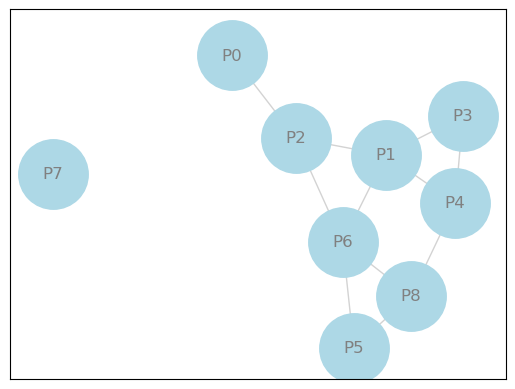

In [24]:
Index1.show_relatedness()